# **Capítulo 4: Fundamentos del Procesamiento Digital de Imágenes**

```
 Libro:  Procesamiento Digital de Voz e Imágenes en la Era de la Inteligencia Artificial
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 4** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.

# **Ejemplo 22.  Ecualización de imagen a escala de grises**

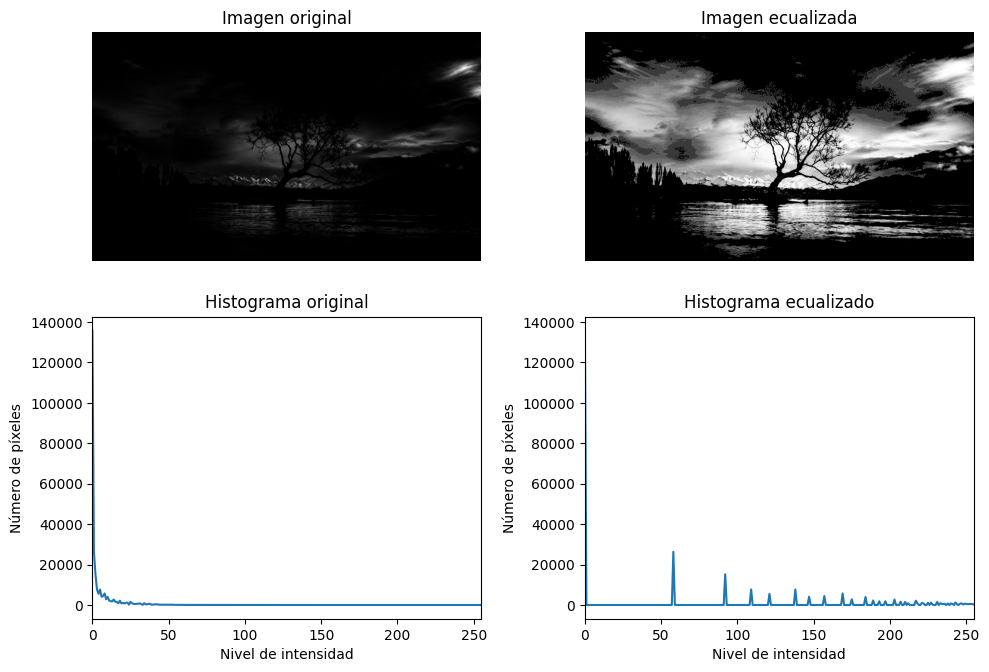

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/imagen_oscura.png', cv2.IMREAD_GRAYSCALE)
img_eq = cv2.equalizeHist(img_dark)

cv2.imwrite("imagen_oscura.png", img_dark)
cv2.imwrite("imagen_ecualizada.png", img_eq)

hist = cv2.calcHist([img], [0], None, [256], [0,256])
hist_eq = cv2.calcHist([img_eq], [0], None, [256], [0,256])

plt.figure(figsize=(10, 7))

# Imagen original
plt.subplot(2, 2, 1); plt.imshow(img, cmap="gray")
plt.title("Imagen original"); plt.axis("off")

# Imagen ecualizada
plt.subplot(2, 2, 2); plt.imshow(img_eq, cmap="gray")
plt.title("Imagen ecualizada"); plt.axis("off")

# Histograma original
plt.subplot(2, 2, 3); plt.plot(hist)
plt.title("Histograma original")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Número de píxeles")
plt.xlim([0, 255])

# Histograma ecualizado
plt.subplot(2, 2, 4); plt.plot(hist_eq)
plt.title("Histograma ecualizado")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Número de píxeles")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

In [ ]:
cv2.imwrite("imagen_gris_ecualizada.png", imagen_eq)

# **Ejemplo 23.  Ecualización de imagen a color**

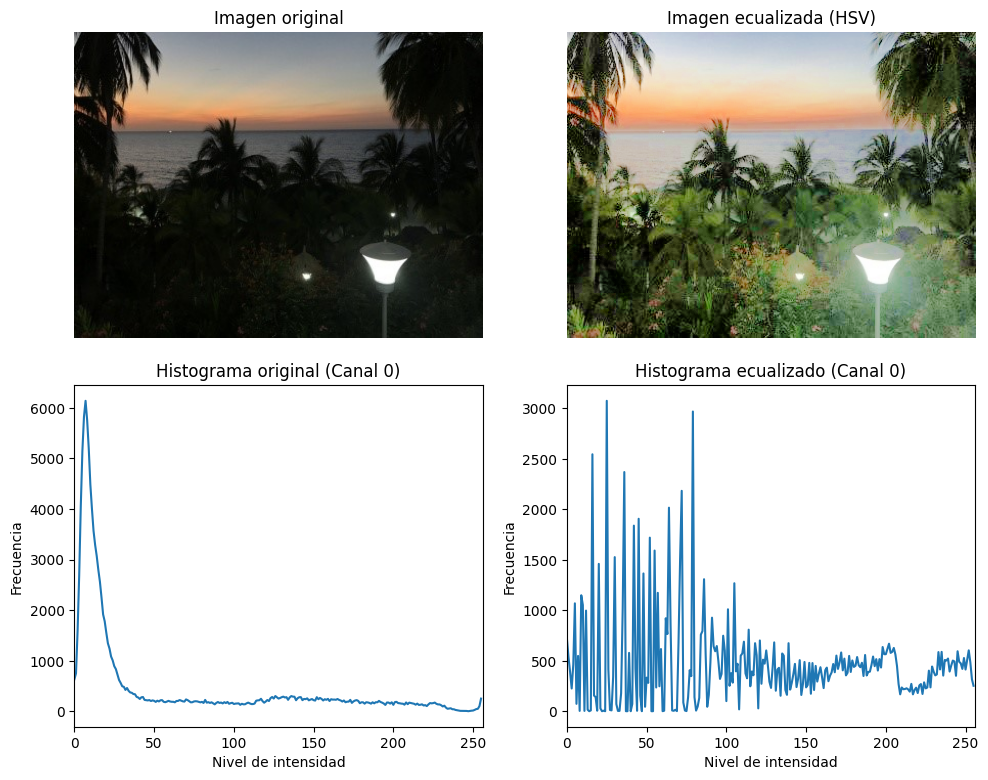

In [ ]:
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread("imagen_color.png") # Leer imagen en color
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB) # Convertir de BGR a RGB
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV) # Convertir de BGR a HSV
H, S, V = cv2.split(imagen_hsv) # Separar canales HSV
V_eq = cv2.equalizeHist(V) # Ecualizar únicamente el canal V
imagen_hsv_eq = cv2.merge([H, S, V_eq]) # Reconstruir imagen HSV
imagen_eq_rgb = cv2.cvtColor(imagen_hsv_eq, cv2.COLOR_HSV2RGB) # Convertir a RGB

# Histograma del canal 0 (R)
hist_original = cv2.calcHist([imagen_rgb], [0], None, [256], [0, 256])
hist_ecualizada = cv2.calcHist([imagen_eq_rgb], [0], None, [256], [0, 256])
plt.figure(figsize=(10, 8))

# Imagen original
plt.subplot(2, 2, 1);plt.imshow(imagen_rgb)
plt.title("Imagen original"); plt.axis("off")

# Imagen ecualizada
plt.subplot(2, 2, 2); plt.imshow(imagen_eq_rgb)
plt.title("Imagen ecualizada (HSV)"); plt.axis("off")

# Histograma original
plt.subplot(2, 2, 3); plt.plot(hist_original)
plt.title("Histograma original (Canal 0)"); plt.xlim([0, 256])
plt.xlabel("Nivel de intensidad"); plt.ylabel("Frecuencia")

# Histograma ecualizado
plt.subplot(2, 2, 4); plt.plot(hist_ecualizada)
plt.title("Histograma ecualizado (Canal 0)");plt.xlim([0, 256])
plt.xlabel("Nivel de intensidad"); plt.ylabel("Frecuencia")

plt.tight_layout(); plt.show()

In [ ]:
# Convertir de RGB a BGR antes de guardar con OpenCV
imagen_eq_bgr = cv2.cvtColor(imagen_eq_rgb, cv2.COLOR_RGB2BGR)

cv2.imwrite("imagen_color_ecualizada.png", imagen_eq_bgr)

# **Ejemplo 24.  Detección de bordes con el algoritmo Canny**

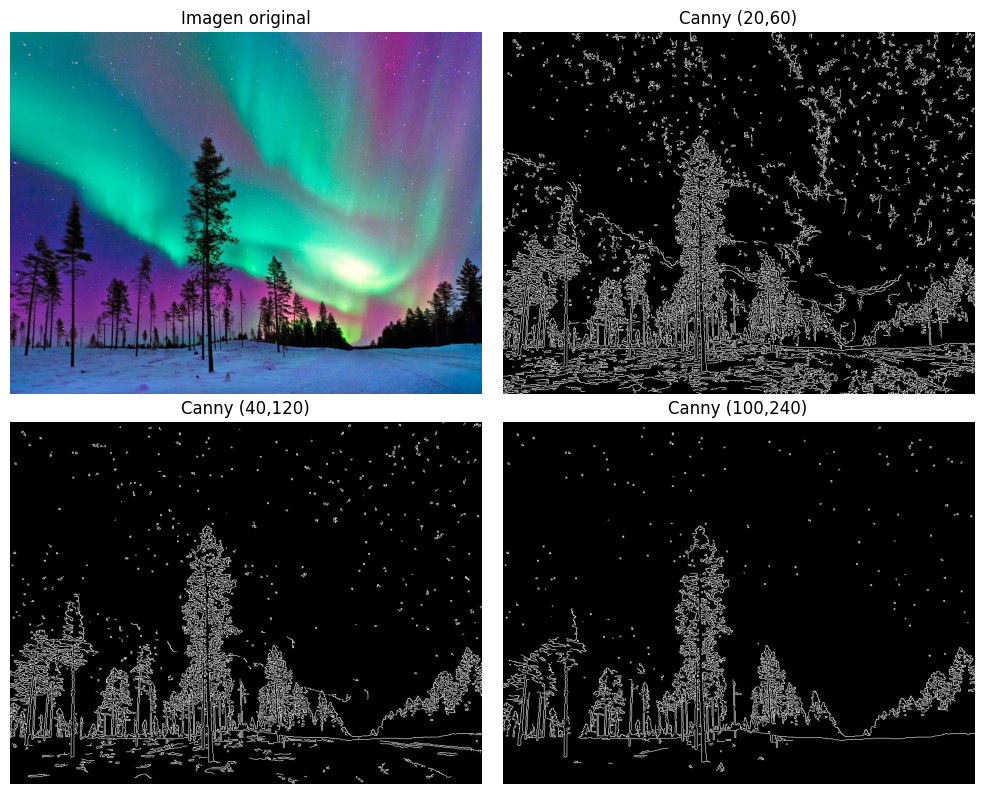

In [ ]:
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread("aurora_boreal.png") # Leer imagen
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB) # Convertir a RGB
imagen_gray = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY) # Escala de grises

canny1 = cv2.Canny(imagen_gray, 20, 60) # Alta sensibilidad
canny2 = cv2.Canny(imagen_gray, 40, 120) # Sensibilidad media
canny3 = cv2.Canny(imagen_gray, 100, 240) # Baja sensibilidad

plt.figure(figsize=(10,8))

plt.subplot(2,2,1); plt.imshow(imagen_rgb)
plt.title("Imagen original"); plt.axis("off")

plt.subplot(2,2,2); plt.imshow(canny1, cmap="gray")
plt.title("Canny (20,60)"); plt.axis("off")

plt.subplot(2,2,3); plt.imshow(canny2, cmap="gray")
plt.title("Canny (40,120)"); plt.axis("off")

plt.subplot(2,2,4); plt.imshow(canny3, cmap="gray")
plt.title("Canny (100,240)"); plt.axis("off")

plt.tight_layout(); plt.show()

# **Ejemplo 25.  Segmentación de imagen con modelo HSV**

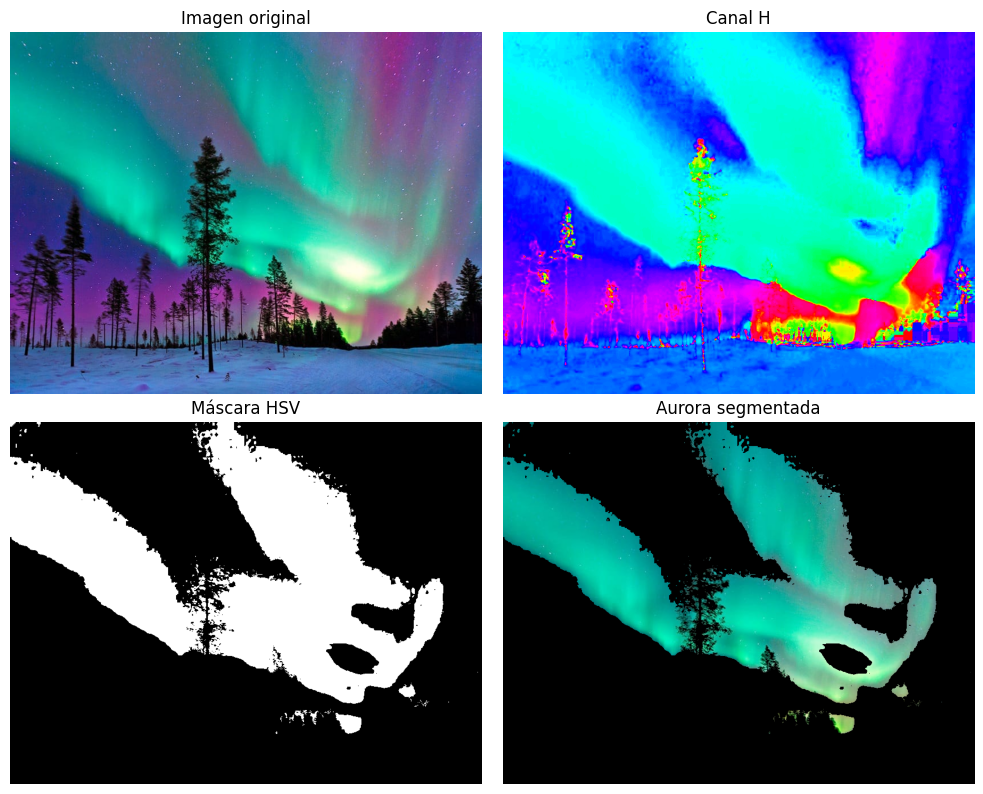

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread("aurora_boreal.png") # Leer imagen
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB) # Convertir a RGB
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV) # Convertir a HSV

lim_inf = np.array([35, 60, 50]) # Límite inferior HSV
lim_sup = np.array([90, 255, 255]) # Límite superior HSV

mascara = cv2.inRange(imagen_hsv, lim_inf, lim_sup) # Crear máscara binaria
segmentada = cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=mascara) # Aplicar máscara

plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1); plt.imshow(imagen_rgb)
plt.title("Imagen original"); plt.axis("off")
plt.subplot(2, 2, 2); plt.imshow(imagen_hsv[:, :, 0], cmap="hsv")
plt.title("Canal H"); plt.axis("off")
plt.subplot(2, 2, 3); plt.imshow(mascara, cmap="gray")
plt.title("Máscara HSV"); plt.axis("off")
plt.subplot(2, 2, 4); plt.imshow(segmentada)
plt.title("Aurora segmentada"); plt.axis("off")
plt.tight_layout(); plt.show()

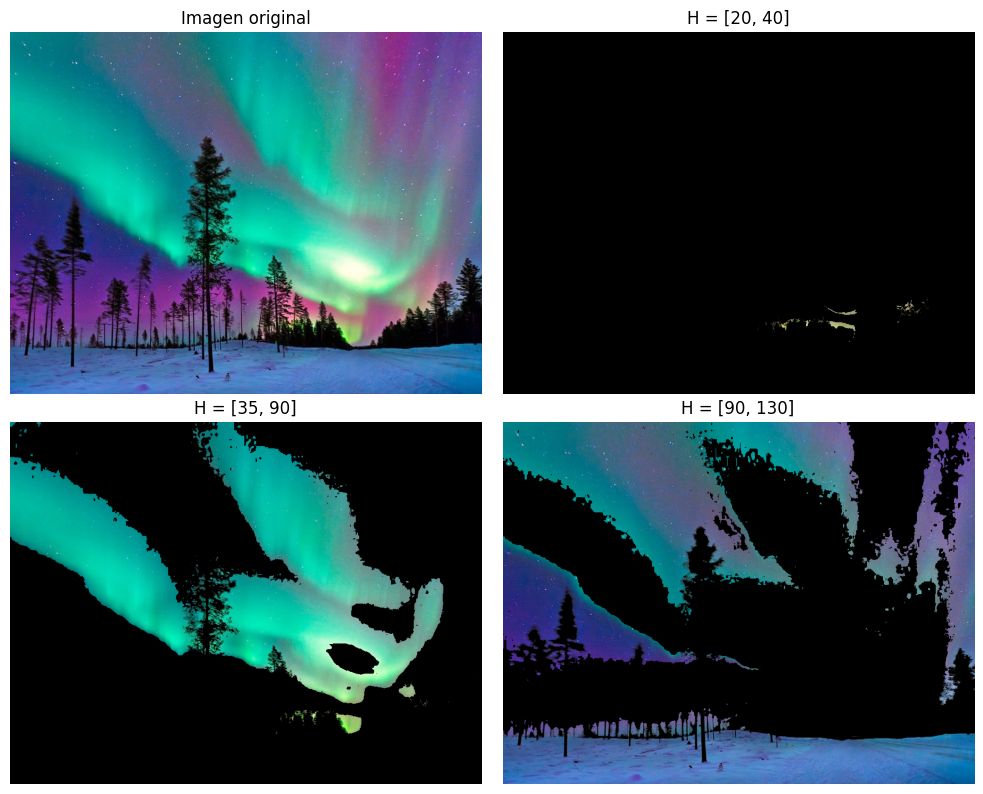

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread("aurora_boreal.png") # Leer imagen
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB) # Convertir a RGB
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV) # Convertir a HSV

# Rangos de H diferentes, manteniendo S y V constantes
lim_inf_1 = np.array([20, 60, 50]); lim_sup_1 = np.array([40, 255, 255])
lim_inf_2 = np.array([35, 60, 50]); lim_sup_2 = np.array([90, 255, 255])
lim_inf_3 = np.array([90, 60, 50]); lim_sup_3 = np.array([130, 255, 255])

mascara_1 = cv2.inRange(imagen_hsv, lim_inf_1, lim_sup_1) # Rango H bajo
mascara_2 = cv2.inRange(imagen_hsv, lim_inf_2, lim_sup_2) # Rango H adecuado
mascara_3 = cv2.inRange(imagen_hsv, lim_inf_3, lim_sup_3) # Rango H alto

seg_1 = cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=mascara_1)
seg_2 = cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=mascara_2)
seg_3 = cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=mascara_3)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1); plt.imshow(imagen_rgb)
plt.title("Imagen original"); plt.axis("off")

plt.subplot(2, 2, 2); plt.imshow(seg_1)
plt.title("H = [20, 40]"); plt.axis("off")

plt.subplot(2, 2, 3); plt.imshow(seg_2)
plt.title("H = [35, 90]"); plt.axis("off")

plt.subplot(2, 2, 4); plt.imshow(seg_3)
plt.title("H = [90, 130]"); plt.axis("off")

plt.tight_layout(); plt.show()

Libro: Procesamiento Digital de Voz e Imágenes  en la Era de la Inteligencia Artificial

---


Versión: 2026 – Material complementario para Google Colab.